In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

In [3]:
df= pd.read_csv('Listings.csv', low_memory=False, encoding='ISO-8859-1')
df.head(10)

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
5,4898654,NEW - Charming apartment Le Marais,505535,2011-04-13,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
6,6021700,2P - Entre Bastille et Republique,8053690,2013-08-09,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
7,6945740,57sqm btw. Bastille & PÃÂ¨re Lachaise,5924709,2013-04-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
8,7491966,Charming appartment near the Parc Buttes Chaumont,35812762,2015-06-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
9,7849932,Bel appartement plein de charme !,20833291,2014-09-02,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [5]:
df['host_since']=pd.to_datetime(df['host_since'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [6]:
paris_listings=df[df['city']=='Paris'].loc[:,['host_since', 'city', 'neighbourhood', 'accommodates', 'price']]
paris_listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   city           64690 non-null  object        
 2   neighbourhood  64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [7]:
paris_listings.describe(include=[np.number])

,accommodates,price
count,64690.000000,64690.000000
mean,3.037997,113.096445
std,1.588766,214.433668
min,0.000000,0.000000
25%,2.000000,59.000000
50%,2.000000,80.000000
75%,4.000000,120.000000
max,16.000000,12000.000000


In [8]:
paris_listings_neighbourhood=paris_listings.groupby('neighbourhood')['price'].mean().sort_values().to_frame()
paris_listings_neighbourhood.tail()

,price
neighbourhood,
Luxembourg,155.638639
Palais-Bourbon,156.856578
Passy,161.144635
Louvre,175.379972
Elysee,210.536765


In [9]:
paris_listings_accommodates=paris_listings[paris_listings['neighbourhood']=='Elysee'].groupby('accommodates')['price'].mean().sort_values().to_frame()

paris_listings_accommodates

,price
accommodates,
0,0.000000
1,79.522222
3,152.828767
2,155.103352
4,212.096070
5,328.817073
6,355.508571
8,405.518519
7,411.538462


In [59]:
paris_listings_over_time=(
    paris_listings
    .set_index('host_since')
    .resample('Y')
    .agg({
        'neighbourhood':'count',
        'price':'mean'
    })
)
paris_listings_over_time

,neighbourhood,price
host_since,,
2008-12-31,4,77.750000
2009-12-31,106,159.641509
2010-12-31,416,125.031250
2011-12-31,1339,124.828230
2012-12-31,4592,111.578615
2013-12-31,8142,107.096414
2014-12-31,10922,100.253800
2015-12-31,12147,103.646250
2016-12-31,8871,114.159847


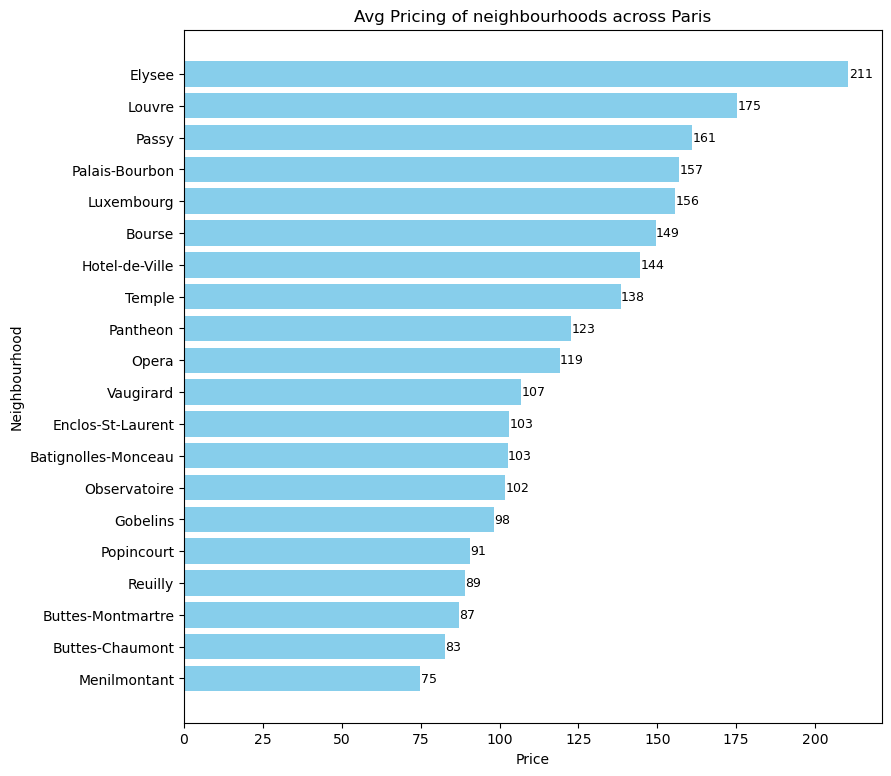

In [11]:
plt.figure(figsize=(9,9))
bars=plt.barh(paris_listings_neighbourhood.index, paris_listings_neighbourhood['price'], color='skyblue')
plt.xlabel('Price')
plt.ylabel('Neighbourhood')
plt.title('Avg Pricing of neighbourhoods across Paris')
for bar in bars:
    plt.text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2,f"{bar.get_width():,.0f}", va='center',fontsize=9)
plt.show()

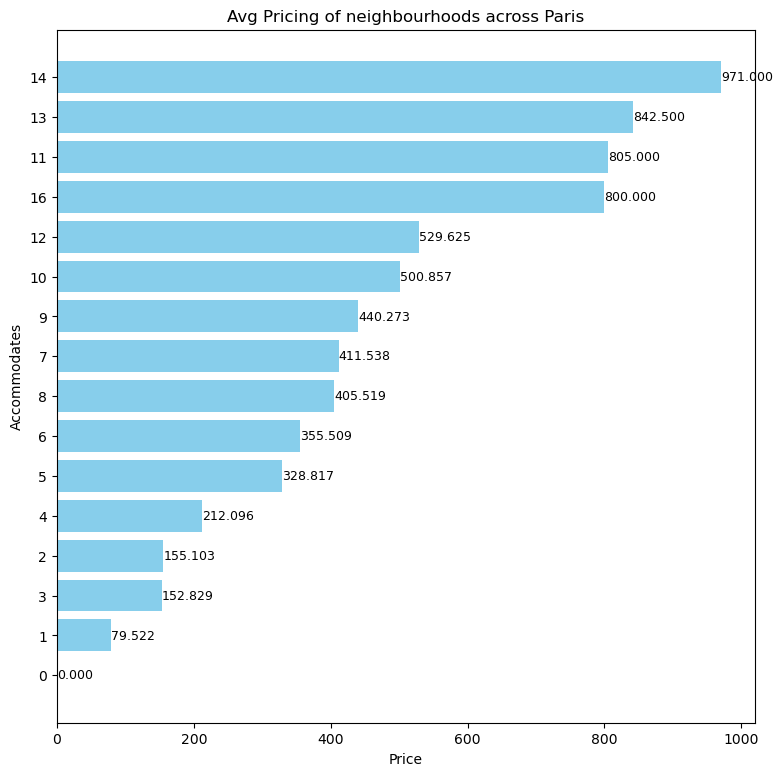

In [22]:
plt.figure(figsize=(9,9))
bars=plt.barh(paris_listings_accommodates.index.astype(str), paris_listings_accommodates['price'], color='skyblue')
plt.xlabel('Price')
plt.ylabel('Accommodates')
plt.title('Avg Pricing of neighbourhoods across Paris')
for bar in bars:
    plt.text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2,f"{bar.get_width():,.3f}", va='center',fontsize=9)

plt.yticks(np.arange(len(paris_listings_accommodates)),labels=paris_listings_accommodates.index)

plt.show()

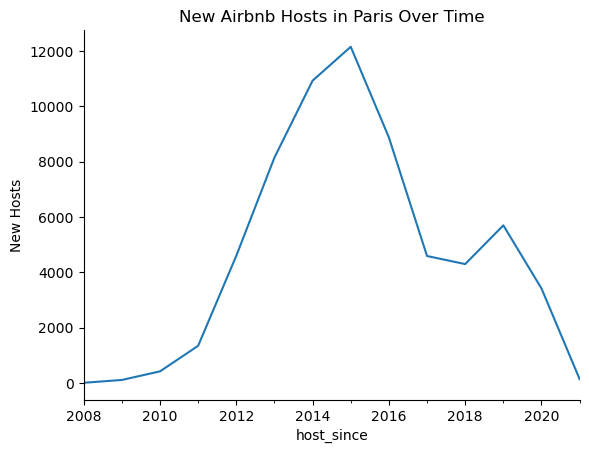

In [63]:
paris_listings_over_time['neighbourhood'].plot(ylabel='New Hosts', title='New Airbnb Hosts in Paris Over Time')
sns.despine()

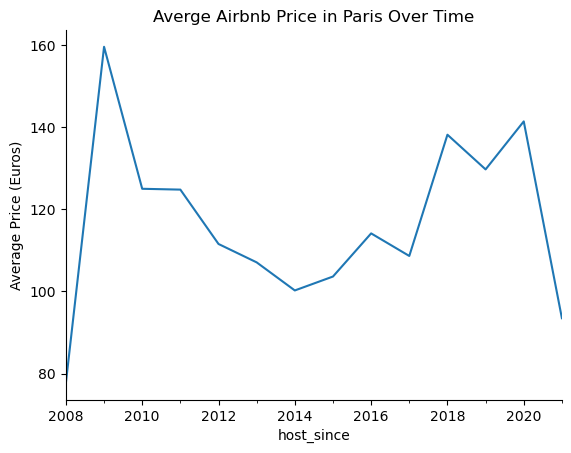

In [64]:
paris_listings_over_time['price'].plot(ylabel='Average Price (Euros)', title='Averge Airbnb Price in Paris Over Time')
sns.despine()

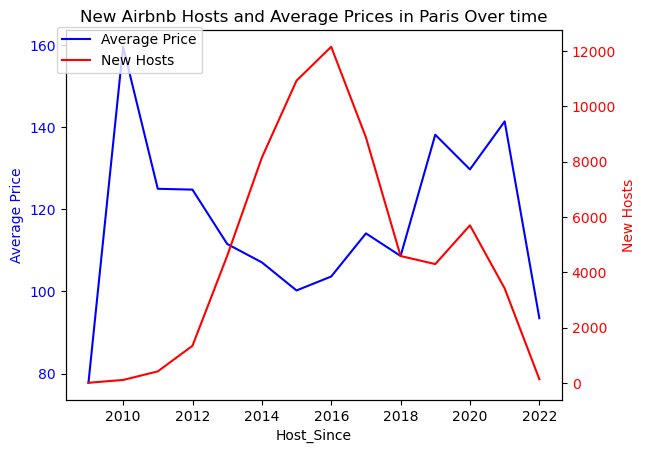

In [66]:
fig, ax1 = plt.subplots()

# Plot the first dataset on the primary y-axis (ax1)
ax1.plot(paris_listings_over_time.index, paris_listings_over_time['price'], color='blue', label='Average Price')
ax1.set_xlabel('Host_Since')
ax1.set_ylabel('Average Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()


ax2.plot(paris_listings_over_time.index, paris_listings_over_time['neighbourhood'], color='red', label='New Hosts')
ax2.set_ylabel('New Hosts', color='red')
ax2.tick_params(axis='y', labelcolor='red')


plt.title('New Airbnb Hosts and Average Prices in Paris Over time')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9)) # Adjust legend position as needed


plt.show()